# pyvisco tutorial

End-to-end walkthrough of the pyvisco workflow on a frequency-domain
Eplexor measurement. Mirrors what the `LinViscoFit.ipynb` Voila app does,
but without `ipywidgets` — every step is a plain function call so this
notebook also runs in headless / CI environments.

Steps:

1. Load raw measurement data
2. Fit shift factors and assemble a master curve
3. Fit WLF + polynomial shift functions
4. Smooth the master curve
5. Discretize and fit a Prony series
6. Plot the resulting Generalized Maxwell model
7. Optional: minimize the number of Prony terms
8. Export results to a zip archive

In [1]:
%matplotlib inline
from pathlib import Path

import pyvisco as visco
from pyvisco import styles

styles.format_fig()

SAMPLE_DATA = Path('..') / 'sample_data'

## 1. Load raw measurement data

In [2]:
modul = 'E'  # tensile (use 'G' for shear)
RefT = -5    # reference temperature in degC (must match a measurement set)

epl_raw = visco.load.file(SAMPLE_DATA / 'freq_Eplexor_raw.xls')
df_raw, arr_RefT, units = visco.load.Eplexor_raw(epl_raw, modul)
df_raw.head()

,f_set,E_stor,E_loss,E_comp,tan_del,T,Set,T_round
0,0.100000,8097.175545,93.074490,8097.710459,0.011495,-49.9612,0,-50.0
1,0.215443,8576.843825,118.193495,8577.658171,0.013781,-49.9617,0,-50.0
2,0.464159,8725.535057,124.843425,8726.428130,0.014308,-49.7383,0,-50.0
3,1.000000,8781.764697,139.916786,8782.879249,0.015933,-49.8128,0,-50.0
4,2.154430,8877.948335,160.288252,8879.395192,0.018055,-49.8721,0,-50.0


## 2. Fit shift factors and assemble the master curve

Here we let pyvisco fit the shift factors directly from the raw data.
If you have measured shift factors, load them with `visco.load.user_shift`
instead.

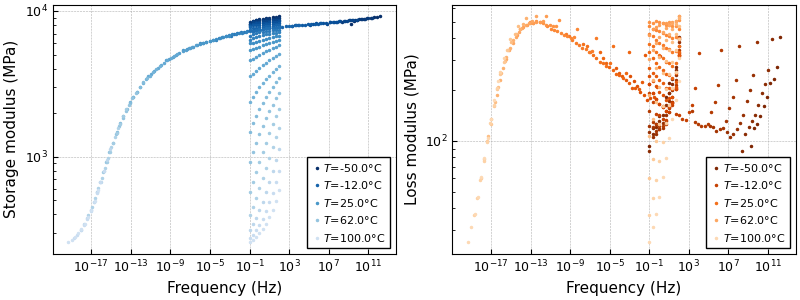

In [3]:
df_aT, dshift = visco.master.get_aT(df_raw, RefT)
df_master = visco.master.get_curve(df_raw, df_aT, RefT)

fig_master_shift, _ = visco.master.plot_shift(df_raw, df_master, units)

## 3. Fit shift functions

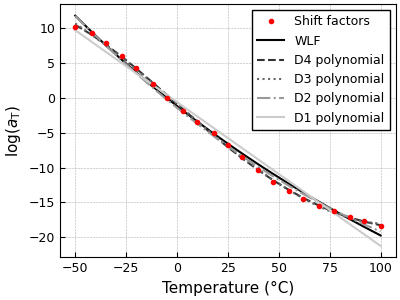

In [4]:
df_WLF = visco.shift.fit_WLF(df_master.RefT, df_aT)
df_poly_C, df_poly_K = visco.shift.fit_poly(df_aT)

fig_shift, df_shift = visco.shift.plot(df_aT, df_WLF, df_poly_C)

## 4. Smooth the master curve

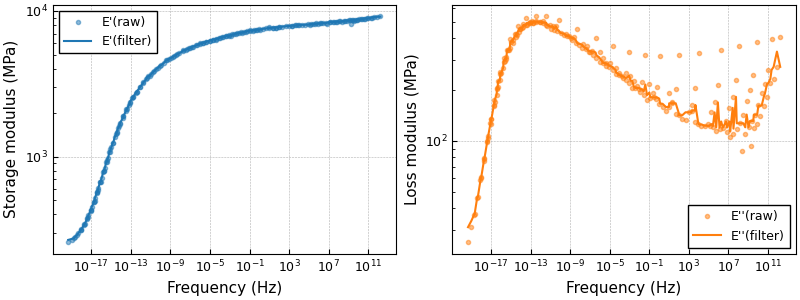

In [5]:
win = 5  # smoothing window
df_master = visco.master.smooth(df_master, win)
fig_smooth = visco.master.plot_smooth(df_master, units)

## 5. Discretize and fit a Prony series

`visco.prony.discretize` chooses a default number of Prony terms based on
the frequency range of the master curve. For manual control, see
`visco.prony.discretize(df_master, nprony=...)`.

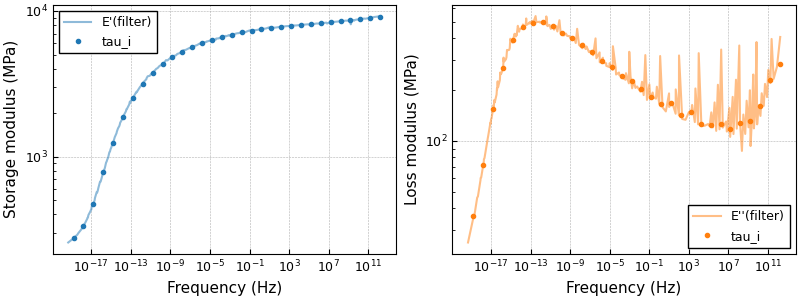

In [6]:
df_dis = visco.prony.discretize(df_master)
fig_dis = visco.prony.plot_dis(df_master, df_dis, units)

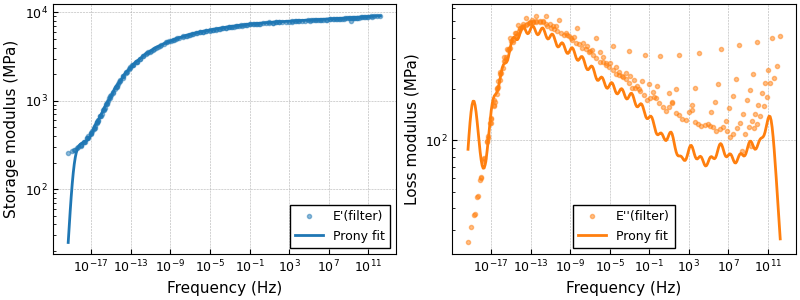

,tau_i,alpha_i,E_0,E_i
1,1.000000e-13,0.000536,9144.791876,4.900454
2,1.000000e-12,0.027192,9144.791876,248.664731
3,1.000000e-11,0.013440,9144.791876,122.903633
4,1.000000e-10,0.015816,9144.791876,144.631602
5,1.000000e-09,0.012125,9144.791876,110.876548
6,1.000000e-08,0.012120,9144.791876,110.836122
7,1.000000e-07,0.015760,9144.791876,144.122520
8,1.000000e-06,0.011513,9144.791876,105.287733
9,1.000000e-05,0.011704,9144.791876,107.029088
10,1.000000e-04,0.015478,9144.791876,141.539275


In [7]:
prony, df_GMaxw = visco.prony.fit(df_dis)
fig_fit = visco.prony.plot_fit(df_master, df_GMaxw, units)
prony['df_terms']

## 6. Plot the Generalized Maxwell model

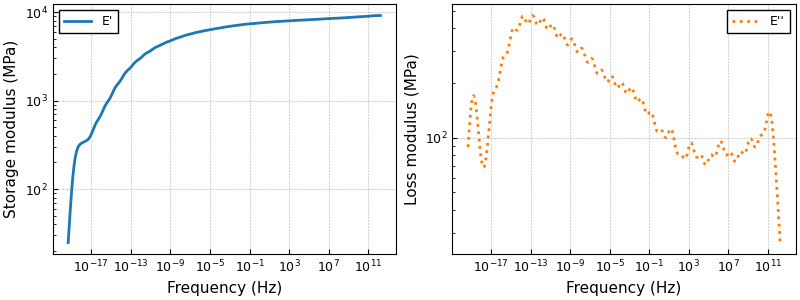

In [8]:
fig_GMaxw = visco.prony.plot_GMaxw(df_GMaxw, units)

## 7. Optional: minimize the number of Prony terms

Re-fits the master curve for a range of Prony-term counts and identifies
the smallest series that still meets a residual-error threshold.

Prony series N = 30: Convergence criterion reached!
Prony series N = 28: Convergence criterion reached!
Prony series N = 26: Convergence criterion reached!
Prony series N = 24: Convergence criterion reached!
Prony series N = 22: Convergence criterion reached!
Prony series N = 20: Convergence criterion reached!
Prony series N = 19: Convergence criterion reached!
Prony series N = 18: Convergence criterion reached!
Prony series N = 17: Convergence criterion reached!
Prony series N = 16: Convergence criterion reached!
Prony series N = 15: Convergence criterion reached!
Prony series N = 14: Convergence criterion reached!
Prony series N = 13: Convergence criterion reached!
Prony series N = 12: Convergence criterion reached!
Prony series N = 11: Convergence criterion reached!
Prony series N = 10: Convergence criterion reached!
Prony series N = 09: Convergence criterion reached!
Prony series N = 08: Convergence criterion reached!
Prony series N = 07: Convergence criterion reached!
Prony series

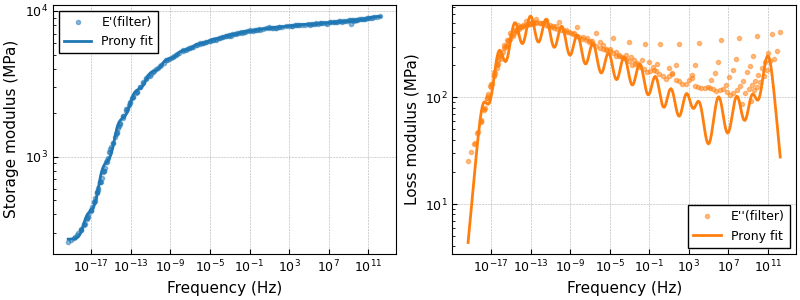

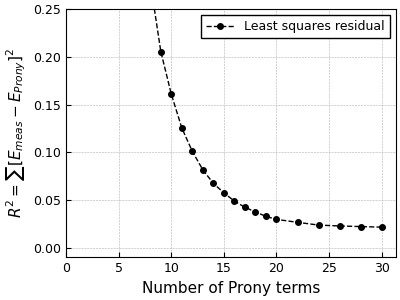

Optimum number of Prony terms: 19


In [9]:
dict_prony, N_opt, N_opt_err = visco.opt.nprony(df_master, prony, window='min')
df_GMaxw_opt, fig_opt = visco.opt.plot_fit(df_master, dict_prony, N_opt, units)
fig_res = visco.opt.plot_residual(N_opt_err)
print(f'Optimum number of Prony terms: {N_opt}')

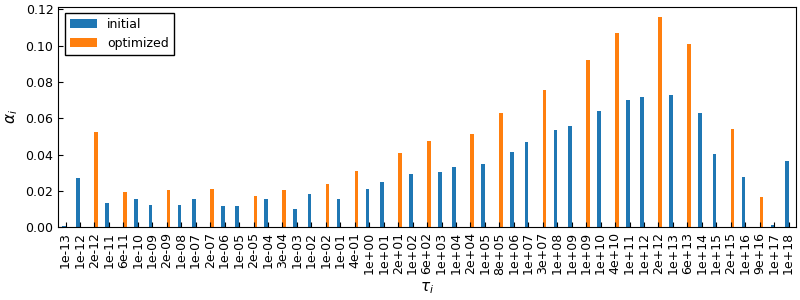

In [10]:
fig_coeff = visco.prony.plot_param(
    [prony, dict_prony[N_opt]],
    ['initial', 'optimized'],
)

## 8. Export results

Bundle the dataframes and figures into a zip archive, identical to what
the Voila app's *Download zip* button produces.

In [11]:
from pyvisco import out

files = {
    'df_master': out.to_csv(df_master, units),
    'df_aT': out.to_csv(df_aT, units),
    'df_shift_WLF': out.to_csv(df_WLF, units),
    'df_prony_terms': prony['df_terms'].to_csv(),
    'fig_master_shift': fig_master_shift,
    'fig_shift': fig_shift,
    'fig_smooth': fig_smooth,
    'fig_dis': fig_dis,
    'fig_fit': fig_fit,
    'fig_GMaxw': fig_GMaxw,
}

from pyvisco.inter import generate_zip  # helper from the Voila app module

archive = generate_zip(files)
print(f'Generated archive: {len(archive)} bytes')

Generated archive: 2047272 bytes
